# Music Noise Analysis

In [1]:
import os
import json
import torch
import numpy as np
import pandas as pd


def load_dataset(path):
    """
    Load dataset from the specified path.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"Dataset not found at {path}")
    
    def inverse_split_dict(split_dict):
        # Add split column to dvi2Torch based on dvi2_torch["split"]
        clique_to_split = {}
        for split_name, sub_dict in split_dict.items():
            for clique in sub_dict.keys():
                clique_to_split[clique] = split_name
        return clique_to_split

    if path.endswith(".json"):
        with open(path, "r") as f:
            meta = json.load(f)
    elif path.endswith(".pt"):
        meta = torch.load(path, weights_only=False)
    if isinstance(meta, dict) and "info" in meta:
        info =  meta["info"]
        split = meta["split"]
    else:
        info, split = meta

    df = pd.DataFrame.from_dict(info, orient="index")
           
    clique2split = inverse_split_dict(split)
    df["split"] = df["clique"].map(clique2split)
    
    if "youtube_id" not in df.columns:
        df["youtube_id"] = df.filename.apply(lambda x: x.split("/")[-1].split(".")[0])
    
    df["dvi"] = ~df.apply(lambda x: x.youtube_id in x.version, axis=1)
    
    return df, meta    

df, _ = load_dataset("data/final_se/divers_se.pt")


## Overall Music vs. Noise Distribution

In [2]:
import numpy as np

all_vals = np.concatenate(df["music_segment_inds"].values)

music_seconds = np.sum(all_vals == 1)
noise_seconds = np.sum(all_vals == 0)

music_minutes = music_seconds / 60
noise_minutes = noise_seconds / 60

music_hours = music_seconds / 3600
noise_hours = noise_seconds / 3600

print(f"Total music duration: {music_seconds} seconds ({music_minutes:.2f} minutes, {music_hours:.2f} hours)")
print(f"Total noise duration: {noise_seconds} seconds ({noise_minutes:.2f} minutes, {noise_hours:.2f} hours)")
print(f"Music to noise ratio: {music_seconds / (music_seconds + noise_seconds):.2f}")


Total music duration: 231656075 seconds (3860934.58 minutes, 64348.91 hours)
Total noise duration: 8732556 seconds (145542.60 minutes, 2425.71 hours)
Music to noise ratio: 0.96


## Per Version Statistics

### Fractions

In [3]:
pd.options.display.float_format = '{:.3f}'.format

df["music_frac"] = df["music_segment_inds"].apply(lambda x: np.mean(x))
df["noise_frac"] = 1 - df["music_frac"]
df["music_frac"].describe()


count   1102317.000
mean          0.978
std           0.085
min           0.001
25%           1.000
50%           1.000
75%           1.000
max           1.000
Name: music_frac, dtype: float64

In [10]:
df.loc[df.dvi == 1, "music_frac"].describe()


count   462802.000
mean         0.996
std          0.028
min          0.005
25%          1.000
50%          1.000
75%          1.000
max          1.000
Name: music_frac, dtype: float64

In [13]:
df.loc[df.tags_yt_title.apply(lambda x: len(x) > 0), "music_frac"].describe()


count   224009.000
mean         0.951
std          0.124
min          0.002
25%          0.975
50%          1.000
75%          1.000
max          1.000
Name: music_frac, dtype: float64

In [14]:
df.loc[df.tags_yt_title.apply(lambda x: len(x) == 0) & df.dvi == False, "music_frac"].describe()


count   645232.000
mean         0.965
std          0.107
min          0.001
25%          0.990
50%          1.000
75%          1.000
max          1.000
Name: music_frac, dtype: float64

### Mean Segment Length


In [4]:
df["avg_music_segment_len"] = df["music_segment_inds"].apply(
    lambda x: np.mean([len(list(g)) for k, g in __import__("itertools").groupby(x) if k == 1]) if any(x) else 0
)
df["avg_noise_segment_len"] = df["music_segment_inds"].apply(
    lambda x: np.mean([len(list(g)) for k, g in __import__("itertools").groupby(x) if k == 0]) if any(x) else 0
)

print("Average music segment length (seconds):")
print(df["avg_music_segment_len"].describe())
print("\nAverage noise segment length (seconds):")
print(df["avg_noise_segment_len"].describe())


/home/sha/anaconda3/envs/discogs-vi2/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/sha/anaconda3/envs/discogs-vi2/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Average music segment length (seconds):
count   1102317.000
mean        193.745
std         100.119
min           1.000
25%         140.000
50%         179.000
75%         233.000
max        1191.000
Name: avg_music_segment_len, dtype: float64

Average noise segment length (seconds):
count   231903.000
mean        14.640
std         32.626
min          1.000
25%          2.333
50%          6.000
75%         14.000
max       1161.000
Name: avg_noise_segment_len, dtype: float64


### Longest consecutive

In [5]:
def longest_run(arr, value):
    max_run = run = 0
    for v in arr:
        if v == value:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0
    return max_run

df["longest_music_run_sec"] = df["music_segment_inds"].apply(lambda x: longest_run(x, 1))
df["longest_noise_run_sec"] = df["music_segment_inds"].apply(lambda x: longest_run(x, 0))

print("Longest music run (seconds):")
print(df["longest_music_run_sec"].describe())
print("\nLongest noise run (seconds):")
print(df["longest_noise_run_sec"].describe())


Longest music run (seconds):
count   1102317.000
mean        203.208
std         100.103
min           1.000
25%         147.000
50%         185.000
75%         240.000
max        1191.000
Name: longest_music_run_sec, dtype: float64

Longest noise run (seconds):
count   1102317.000
mean          5.060
std          26.423
min           0.000
25%           0.000
50%           0.000
75%           0.000
max        1161.000
Name: longest_noise_run_sec, dtype: float64


### Number of transitions

In [6]:
def count_transitions(arr):
    return np.sum(np.diff(arr) != 0)

df["num_transitions"] = df["music_segment_inds"].apply(count_transitions)

print("Number of transitions between music and noise:")
print(df["num_transitions"].describe())


Number of transitions between music and noise:
count   1102317.000
mean          0.785
std           3.415
min           0.000
25%           0.000
50%           0.000
75%           0.000
max         196.000
Name: num_transitions, dtype: float64


## Analysis per Tag-based Concept

In [7]:
from itertools import chain

def has_any_tag(row_tags, concept_tags):
    return any(tag in row_tags for tag in concept_tags)

concepts = {
    "background": ["background"],
    "backingtrack": ["backingtrack"],
    "cover": ["cover"],
    "instrumental'": ["instrumental", "karaoke"],
    "official": ["official"],
    "reaction'": ["firsttimehearing", "firsttimelistening", "react", "reaction", "reacts"],
    "studio": ["studio"],
    "tutorial'": ["howtoplay", "howtosing", "lesson", "tutorial"],
}

concept_music = {}

for concept, tags in concepts.items():
    mask = df["tags_yt_title"].apply(lambda x: has_any_tag(x, tags))
    concept_music[concept] = df.loc[mask, "music_frac"]
    

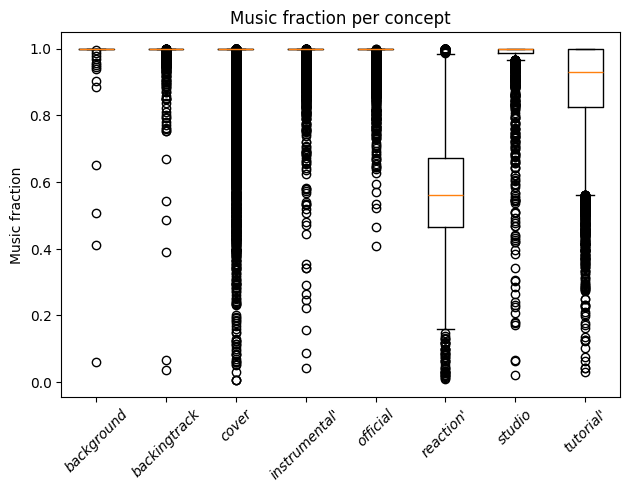

In [8]:
import matplotlib.pyplot as plt

plt.style.use('tableau-colorblind10')


data = [vals for vals in concept_music.values()]
labels = list(concept_music.keys())

plt.figure()
plt.boxplot(data, tick_labels=labels)
plt.xticks(range(1, len(labels)+1), labels, rotation=45, fontstyle="italic")
plt.ylabel("Music fraction")
plt.tight_layout()
plt.savefig("figures/music_fraction_per_concept_boxplot.pdf")

plt.title("Music fraction per concept")
plt.show()


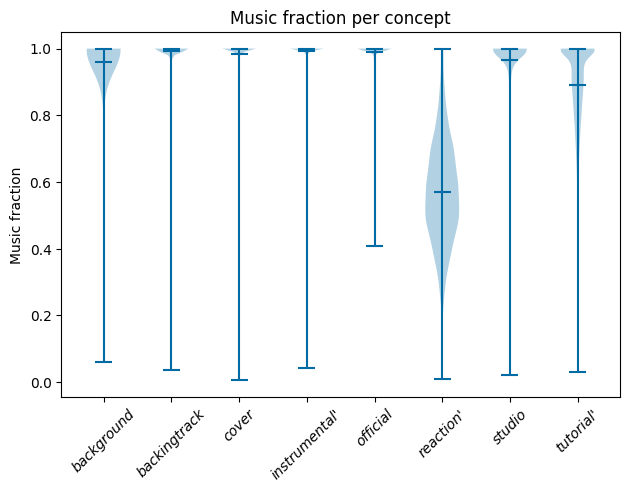

In [9]:
plt.style.use('tableau-colorblind10')

plt.figure()
plt.violinplot(data, showmeans=True)
plt.xticks(range(1, len(labels)+1), labels, rotation=45, fontstyle="italic")
plt.ylabel("Music fraction")
plt.tight_layout()
plt.savefig("figures/music_fraction_per_concept_violinplot.pdf")

plt.title("Music fraction per concept")
plt.show()
